Importing Libraries

In [29]:
# Statistics and using the dataset
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For encoding the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#For training the data
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# To measure the accuracy of the data
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

Loading the dataset

In [2]:
df = pd.read_csv('IRIS.csv')

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Basic description of the data

In [3]:
df.shape

(150, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


Data Visualization

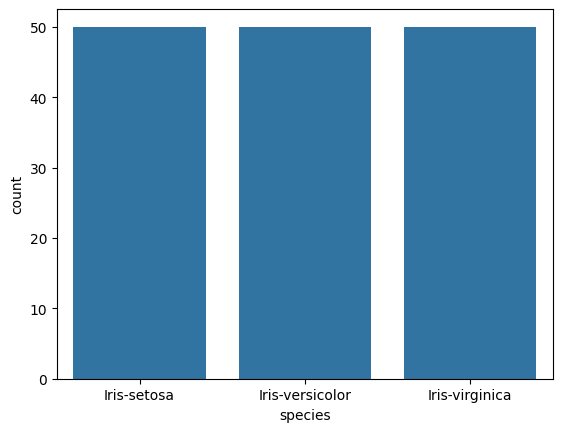

In [7]:
sns.countplot(x='species', data=df)
plt.show()

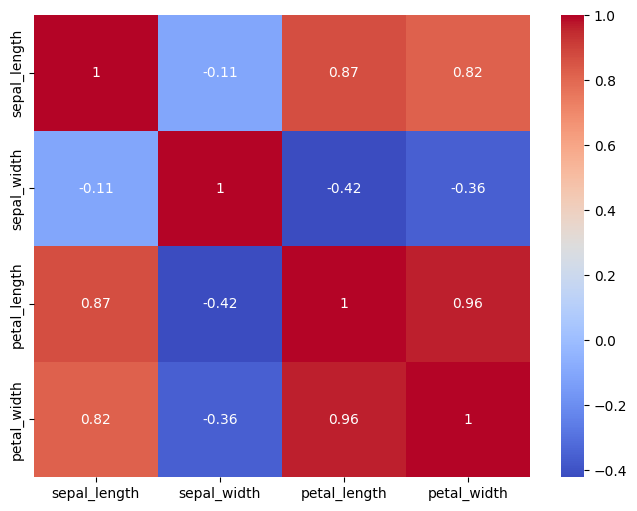

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop('species', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Data Cleaning and Encoding

In [9]:
X = df.drop('species', axis=1)
Y = df['species']

In [10]:
le = LabelEncoder()

Y = le.fit_transform(Y)

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

First Model: Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=200)

lr.fit(X_train, Y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, pred_lr))

Accuracy: 1.0


Second Model: KNN Model

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, Y_train)

pred_knn = knn.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, pred_knn))

Accuracy: 1.0


Third Model: Decision Tree

In [22]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, Y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, pred_dt))

Accuracy: 1.0


Fourth Model: Random Forest

In [23]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, Y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, pred_rf))

Accuracy: 1.0


Results: Accuracy Score

In [24]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(Y_test,pred_lr),
        accuracy_score(Y_test,pred_knn),
        accuracy_score(Y_test,pred_dt),
        accuracy_score(Y_test,pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,KNN,1.0
2,Decision Tree,1.0
3,Random Forest,1.0


Results: Classification Report

In [25]:
print(classification_report(Y_test, pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Results: Confusion Matrix

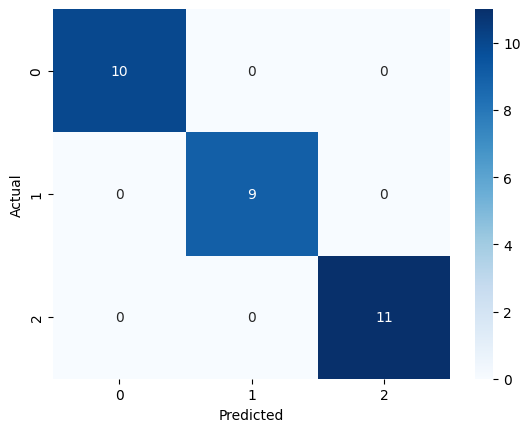

In [26]:
cm = confusion_matrix(Y_test, pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature Importance

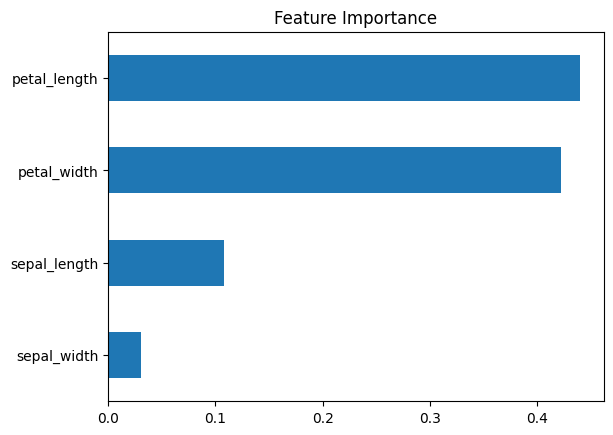

In [27]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh'
)

plt.title("Feature Importance")
plt.show()

Testing

In [28]:
sepal_length = float(input("Enter Sepal Length: "))
sepal_width = float(input("Enter Sepal Width: "))
petal_length = float(input("Enter Petal Length: "))
petal_width = float(input("Enter Petal Width: "))

sample = pd.DataFrame({
    'sepal_length': [sepal_length],
    'sepal_width': [sepal_width],
    'petal_length': [petal_length],
    'petal_width': [petal_width]
})
prediction = rf.predict(sample)
print("Predicted Species:", le.inverse_transform(prediction)[0])

Enter Sepal Length: 2.00
Enter Sepal Width: 1.50
Enter Petal Length: 2.25
Enter Petal Width: 1.75
Predicted Species: Iris-setosa
